In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset_raw = pd.read_csv('sri_lanka_irrigation_dataset.csv') 
print(f"Shape: {dataset_raw.shape} → {dataset_raw.shape[0]} records, {dataset_raw.shape[1]} features") 
pd.set_option('display.max_columns', None) 
dataset_raw.head()

Shape: (10000, 28) → 10000 records, 28 features


,Field_Cycle_ID,District,Climate_Zone,Season,Crop_Type,Crop_Growth_Stage,Stage_Duration_days,Soil_Type,Soil_pH,Soil_Moisture_pct,Organic_Carbon_pct,Electrical_Conductivity_dSm,Tmax_C,Tmin_C,Temperature_C,Humidity_pct,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Reference_ET0_mm_day,Crop_Coefficient_Kc,Net_Irrigation_Requirement_mm,Gross_Irrigation_Requirement_mm
0,0,Kalutara,Wet,Maha,Big Onion,Initial,15,Sandy Loam,5.95,15.20,0.89,0.46,28.8,22.6,25.7,85.5,105.3,6.4,5.3,Rainfed,Agro-well,0.92,Yes,13.2,3.77,0.70,0.0,NaN
1,0,Kalutara,Wet,Maha,Big Onion,Development,25,Sandy Loam,5.77,18.50,1.44,0.42,29.2,22.4,25.8,79.3,166.0,5.7,8.1,Rainfed,Agro-well,0.92,Yes,0.0,3.87,0.90,0.0,NaN
2,0,Kalutara,Wet,Maha,Big Onion,Mid-season,35,Sandy Loam,5.90,18.90,1.04,0.37,27.2,23.1,25.1,85.5,104.6,5.9,5.3,Rainfed,Agro-well,0.92,Yes,0.0,2.79,1.05,0.0,NaN
3,0,Kalutara,Wet,Maha,Big Onion,Late-season,20,Sandy Loam,5.85,17.53,0.54,0.44,28.1,22.7,25.4,84.5,112.9,6.2,8.4,Rainfed,Agro-well,0.92,Yes,0.0,3.09,0.75,0.0,NaN
4,1,Monaragala,Intermediate,Maha,Paddy (Rice),Initial,20,Sandy,4.75,9.17,0.42,0.50,29.3,20.3,24.8,80.3,102.6,5.8,9.7,Drip,Agro-well,1.63,No,62.4,4.43,1.05,2.8,3.1


# We drop these columns because they are not necessary to predict the Net Irrigation Requirement (mm).

In [3]:
# Drop both the target variable and the ID column at the start
df_raw = dataset_raw.drop(["Gross_Irrigation_Requirement_mm", "Field_Cycle_ID" , "Previous_Irrigation_mm"], axis=1)

# Here We inspect the dataset at this stage to detect "dirty" (inconsistent/corrupted) entries and identify any null (missing) values across all columns.

In [4]:
# ── 3B. Column-level quality overview ──────────────────────────────────────
def scan_data_quality(df):
    hidden_numeric, dirty_categorical = [], []
    for col in df.select_dtypes(include=['object', 'string']).columns:
        vals = df[col].dropna().unique()
        if vals.size == 0: continue
        
        if pd.to_numeric(pd.Series(vals), errors='coerce').notna().mean() > 0.5 and df[col].nunique() != len(df):
            hidden_numeric.append(col)
        elif vals.size != pd.Series(vals).astype(str).str.strip().nunique():
            dirty_categorical.append(col)
    return hidden_numeric, dirty_categorical

hidden_numeric_cols, dirty_cols_names = scan_data_quality(df_raw)

# Generate Quality Table
col_info = pd.DataFrame({
    'pandas_dtype' : df_raw.dtypes.astype(str),
    'null_count'   : df_raw.isna().sum(),
    'null_%'       : (df_raw.isna().mean() * 100).round(2),
    'n_unique'     : df_raw.nunique(),
    'sample_values': [str(df_raw[c].dropna().unique()[:3].tolist()) for c in df_raw.columns]
}).sort_values('null_%', ascending=False)

print("=== Column Quality Scan ===")
# Inline Row Styling based on row index name
display(col_info.style.apply(lambda row: 
    ['background-color: #ffe6e6'] * len(row) if row.name in hidden_numeric_cols else 
    ['background-color: #fff2cc'] * len(row) if row.name in dirty_cols_names else 
    [''] * len(row), axis=1))

if hidden_numeric_cols: print(f"• Hidden Numeric Columns (Red): {hidden_numeric_cols}")
if dirty_cols_names: print(f"• Dirty Categorical Columns (Yellow): {dirty_cols_names}")
if not hidden_numeric_cols and not dirty_cols_names:print("Wrong data types and dirty entries have been corrected.")

=== Column Quality Scan ===


,pandas_dtype,null_count,null_%,n_unique,sample_values
District,object,0,0.000000,25,"['Kalutara', 'Monaragala', 'Galle']"
Climate_Zone,object,0,0.000000,3,"['Wet', 'Intermediate', 'Dry']"
Season,object,0,0.000000,2,"['Maha', 'Yala']"
Crop_Type,object,0,0.000000,6,"['Big Onion', 'Paddy (Rice)', 'Tomato']"
Crop_Growth_Stage,object,0,0.000000,4,"['Initial', 'Development', 'Mid-season']"
Stage_Duration_days,int64,0,0.000000,11,"[15, 25, 35]"
Soil_Type,object,0,0.000000,4,"['Sandy Loam', 'Sandy', 'Loamy']"
Soil_pH,float64,0,0.000000,350,"[5.95, 5.77, 5.9]"
Soil_Moisture_pct,float64,0,0.000000,2867,"[15.2, 18.5, 18.9]"
Organic_Carbon_pct,float64,0,0.000000,219,"[0.89, 1.44, 1.04]"


Wrong data types and dirty entries have been corrected.


# I am doing this step bacuse to make sure the feature crops Coefficient (Kc) has the informations of  the featueres Crop_Type and Crop_Growth_Stage

In [60]:
# Create a pivot table showing the average, min, and max Kc values 
# broken down by each crop type and its specific growth stage
kc_profile = dataset_raw.groupby(['Crop_Type', 'Crop_Growth_Stage'])['Crop_Coefficient_Kc'].agg(
    Mean_Kc='mean',
    Min_Kc='min',
    Max_Kc='max',
    Record_Count='count'
).reset_index()

# Sort logically to keep crop lifecycle stages cohesive
print("--- Crop Coefficient (Kc) Breakdown by Growth Stage ---")
print(kc_profile.to_string(index=False))

--- Crop Coefficient (Kc) Breakdown by Growth Stage ---
   Crop_Type Crop_Growth_Stage  Mean_Kc  Min_Kc  Max_Kc  Record_Count
   Big Onion       Development     0.90    0.90    0.90           428
   Big Onion           Initial     0.70    0.70    0.70           428
   Big Onion       Late-season     0.75    0.75    0.75           428
   Big Onion        Mid-season     1.05    1.05    1.05           428
       Chili       Development     0.85    0.85    0.85           400
       Chili           Initial     0.60    0.60    0.60           400
       Chili       Late-season     0.90    0.90    0.90           400
       Chili        Mid-season     1.05    1.05    1.05           400
  Green Gram       Development     0.75    0.75    0.75           435
  Green Gram           Initial     0.40    0.40    0.40           435
  Green Gram       Late-season     0.40    0.40    0.40           435
  Green Gram        Mid-season     1.05    1.05    1.05           435
       Maize       Development    

In [6]:
df=df_raw.copy()

# Removing the Duplicate by rows and columns

In [7]:
print("--- Checking for Duplicate Rows ---")
duplicate_row_count = df.duplicated().sum()

if duplicate_row_count > 0:
    df = df.drop_duplicates(keep='first').reset_index(drop=True)
    print(f"✓ Removed {duplicate_row_count} duplicate rows.")
else:
    print("✓ Clean! No duplicate rows detected.")

print(f"Current Shape: {df.shape[0]} rows, {df.shape[1]} features\n")


# --- 2. Lightning-Fast Duplicate Column Investigation ---
print("--- Investigating Duplicate Columns ---")

# Vectorized transpose detection finds identical columns in C-speed, not Python loops
is_duplicate_col = df.T.duplicated(keep='first')

if is_duplicate_col.any():
    # Grab the names of the duplicate columns to be removed
    duplicate_cols = df.columns[is_duplicate_col].tolist()
    print(f"⚠ Found {len(duplicate_cols)} identical duplicate column(s): {duplicate_cols}")
    
    # Optional: Map duplicates to their original columns for clear logging
    for col in duplicate_cols:
        # Find the first column in the dataframe that matches this duplicate column perfectly
        original = df.columns[(df.T == df[col]).all(axis=1)][0]
        print(f"  • Column '{col}' is an identical twin of original column: '{original}'")
        
    print("\nℹ Action: No columns were deleted yet. Please review the twins listed above.")
else:
    print("✓ Clean! No duplicate columns detected.")

print(f"Final Shape: {df.shape[0]} rows, {df.shape[1]} features\n")




--- Checking for Duplicate Rows ---
✓ Clean! No duplicate rows detected.
Current Shape: 10000 rows, 25 features

--- Investigating Duplicate Columns ---
✓ Clean! No duplicate columns detected.
Final Shape: 10000 rows, 25 features



# Splitting the Input featues and Target featute

In [8]:
X = df.drop(columns=['Net_Irrigation_Requirement_mm'])
y = df['Net_Irrigation_Requirement_mm']
print(f"Features matrix X: {X.shape}")
print(f"Target vector  y: {y.shape}")

Features matrix X: (10000, 24)
Target vector  y: (10000,)


# Train set and Test set split

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training Set : {X_train.shape[0]} records")
print(f"Testing Set  : {X_test.shape[0]} records")
print(f"\nTrain Target Mean: {y_train.mean():.2f}")
print(f"Test Target Mean : {y_test.mean():.2f}")

Training Set : 8000 records
Testing Set  : 2000 records

Train Target Mean: 22.42
Test Target Mean : 23.87


# Making each list for the categorical features and numerical feature

In [10]:
# Identify quantitative and qualitative columns from training split
quan = X_train.select_dtypes(include=['number']).columns.tolist()
qual = X_train.select_dtypes(exclude=['number']).columns.tolist()

print(f"Quantitative columns ({len(quan)}): {quan}")
print(f"\nQualitative  columns ({len(qual)}): {qual}")

Quantitative columns (15): ['Stage_Duration_days', 'Soil_pH', 'Soil_Moisture_pct', 'Organic_Carbon_pct', 'Electrical_Conductivity_dSm', 'Tmax_C', 'Tmin_C', 'Temperature_C', 'Humidity_pct', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Reference_ET0_mm_day', 'Crop_Coefficient_Kc']

Qualitative  columns (9): ['District', 'Climate_Zone', 'Season', 'Crop_Type', 'Crop_Growth_Stage', 'Soil_Type', 'Irrigation_Type', 'Water_Source', 'Mulching_Used']


In [11]:
quan

['Stage_Duration_days',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Organic_Carbon_pct',
 'Electrical_Conductivity_dSm',
 'Tmax_C',
 'Tmin_C',
 'Temperature_C',
 'Humidity_pct',
 'Rainfall_mm',
 'Sunlight_Hours',
 'Wind_Speed_kmh',
 'Field_Area_hectare',
 'Reference_ET0_mm_day',
 'Crop_Coefficient_Kc']

In [12]:
qual

['District',
 'Climate_Zone',
 'Season',
 'Crop_Type',
 'Crop_Growth_Stage',
 'Soil_Type',
 'Irrigation_Type',
 'Water_Source',
 'Mulching_Used']

# Here we create a descriptive table with statistical values to find the outliers

In [13]:
# ── Descriptive stats on TRAINING SPLIT only ───────────────────────────────
descriptive = pd.DataFrame(
    index=["Mean","Median","Mode","Q1:25%","Q2:50%","Q3:75%","Q4:100%",
           "IQR","1.5rule","Lesser","Greater","Min","Max","Skewness","Kurtosis"],
    columns=quan
)

for col in quan:
    desc = X_train[col].describe()
    descriptive.loc["Mean",    col] = X_train[col].mean()
    descriptive.loc["Median",  col] = X_train[col].median()
    descriptive.loc["Mode",    col] = X_train[col].mode()[0] if not X_train[col].mode().empty else np.nan
    descriptive.loc["Q1:25%",  col] = desc["25%"]
    descriptive.loc["Q2:50%",  col] = desc["50%"]
    descriptive.loc["Q3:75%",  col] = desc["75%"]
    descriptive.loc["Q4:100%", col] = desc["max"]
    iqr = desc["75%"] - desc["25%"]
    descriptive.loc["IQR",     col] = iqr
    descriptive.loc["1.5rule", col] = 1.5 * iqr
    descriptive.loc["Lesser",  col] = desc["25%"] - 1.5 * iqr
    descriptive.loc["Greater", col] = desc["75%"] + 1.5 * iqr
    descriptive.loc["Min",     col] = X_train[col].min()
    descriptive.loc["Max",     col] = X_train[col].max()
    descriptive.loc["Skewness",col] = X_train[col].skew()
    descriptive.loc["Kurtosis",col] = X_train[col].kurtosis()

display(descriptive)

,Stage_Duration_days,Soil_pH,Soil_Moisture_pct,Organic_Carbon_pct,Electrical_Conductivity_dSm,Tmax_C,Tmin_C,Temperature_C,Humidity_pct,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Reference_ET0_mm_day,Crop_Coefficient_Kc
Mean,25.817125,5.75989,18.235804,1.01689,0.570322,30.746725,22.695162,26.720675,77.31335,130.440237,6.919137,9.477325,0.997371,4.199108,0.830325
Median,25.0,5.75,17.4,0.98,0.54,30.5,22.8,26.6,78.7,103.15,6.8,9.2,0.81,4.17,0.85
Mode,20,5.87,12.6,0.68,0.05,29.5,23.2,26.3,82.2,0.0,6.6,8.2,0.1,3.8,1.05
Q1:25%,20.0,5.33,12.08,0.69,0.37,28.8,21.9,25.6,72.6,48.2,6.1,7.1,0.48,3.62,0.6
Q2:50%,25.0,5.75,17.4,0.98,0.54,30.5,22.8,26.6,78.7,103.15,6.8,9.2,0.81,4.17,0.85
Q3:75%,30.0,6.17,24.67,1.31,0.74,32.6,23.8,27.9,82.8,183.925,7.7,11.5,1.36,4.8,1.05
Q4:100%,60.0,7.9,36.75,2.56,1.84,38.7,27.6,31.8,96.8,920.4,10.7,22.3,4.99,6.56,1.2
IQR,10.0,0.84,12.59,0.62,0.37,3.8,1.9,2.3,10.2,135.725,1.6,4.4,0.88,1.18,0.45
1.5rule,15.0,1.26,18.885,0.93,0.555,5.7,2.85,3.45,15.3,203.5875,2.4,6.6,1.32,1.77,0.675
Lesser,5.0,4.07,-6.805,-0.24,-0.185,23.1,19.05,22.15,57.3,-155.3875,3.7,0.5,-0.84,1.85,-0.075


# Box plots to visualize the outliers

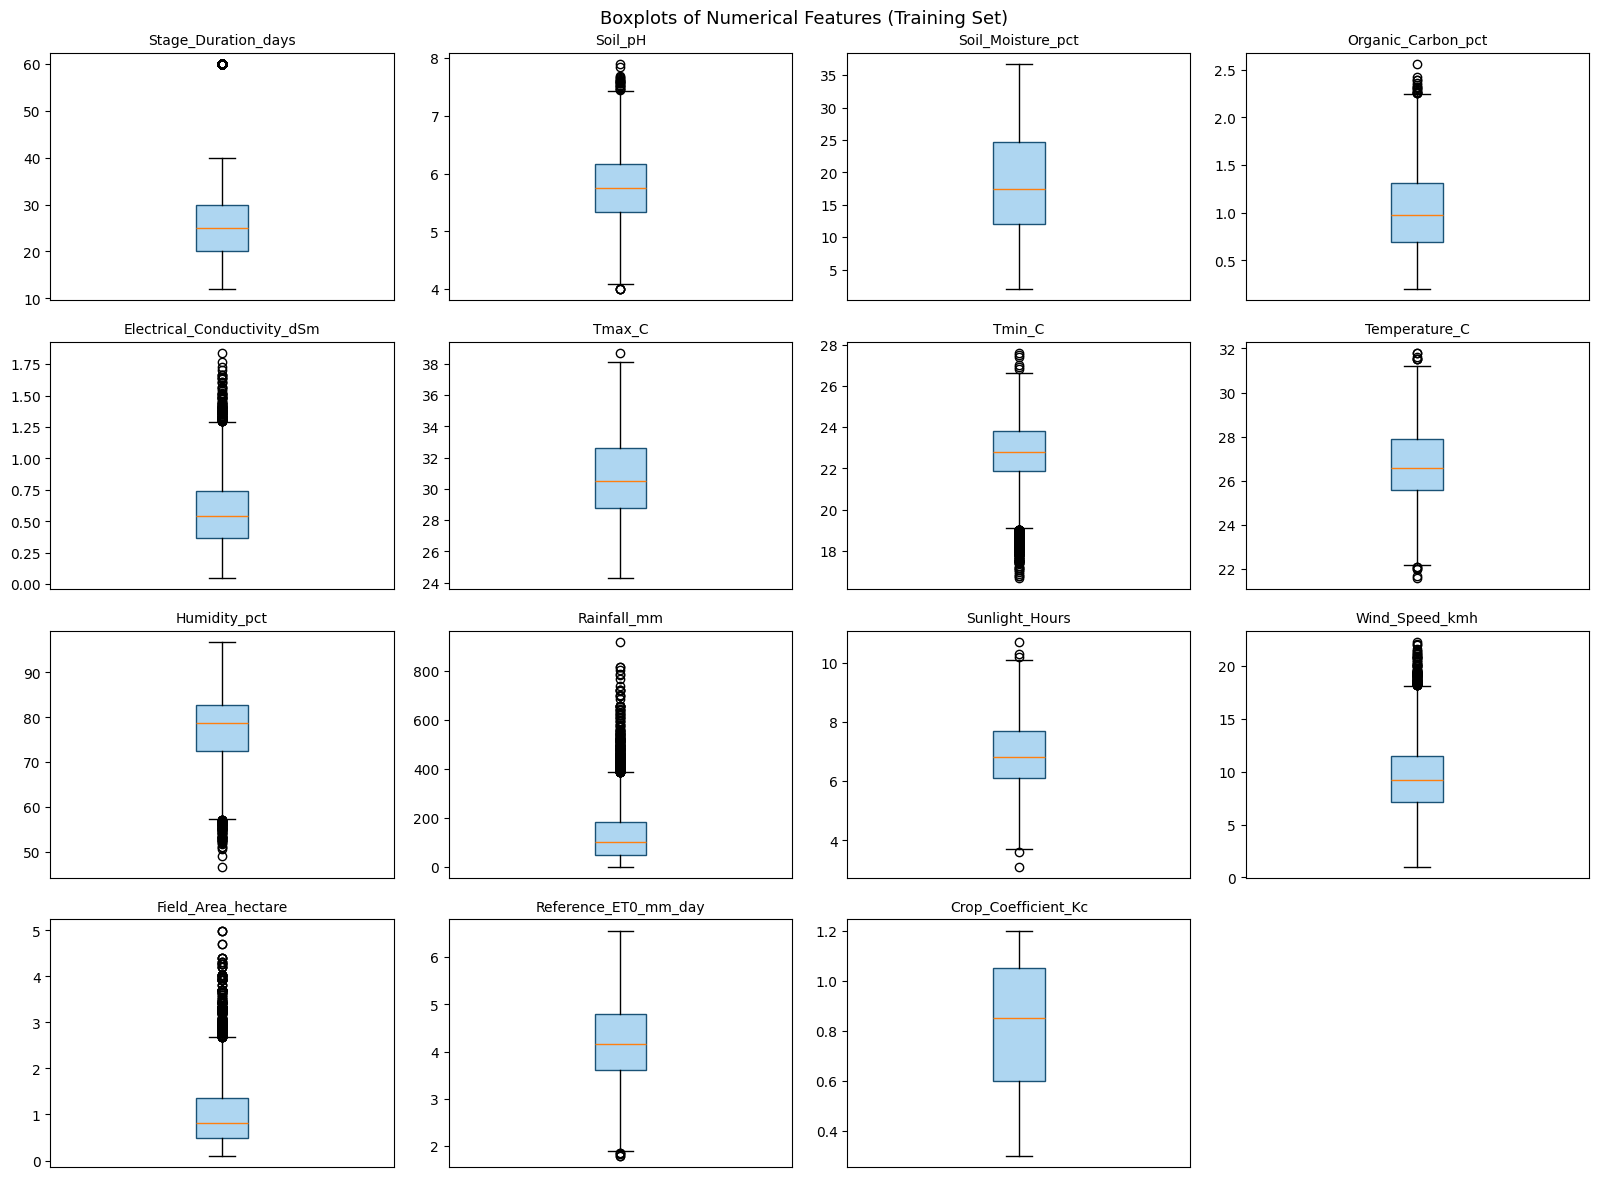

In [14]:
# ── Boxplots for visual outlier detection ──────────────────────────────────
# FIX (NEW STEP): Boxplots were missing in the original notebook
n_cols = 4
n_rows = (len(quan) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(quan):
    axes[i].boxplot(X_train[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#AED6F1', color='#1A5276'))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticks([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots of Numerical Features (Training Set)', fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
def OutlierDetector(Quan, descriptive_df, data_df):
    """
    Identifies low and high outliers, returning master tables with columns organized as:
    column_name -> outlier_count -> outlier_% -> threshold -> outlier_range.
    """
    low_summary_data = []
    high_summary_data = []
    LesserOut = []
    GreaterOut = []
    total_rows = len(data_df)
    
    for columnName in Quan:
        lesser_threshold = descriptive_df.loc["Lesser", columnName]
        greater_threshold = descriptive_df.loc["Greater", columnName]
        
        # 1. Process Low Outliers
        low_vals = data_df[data_df[columnName] < lesser_threshold][columnName].tolist()
        if len(low_vals) > 0:
            LesserOut.append(columnName)
            low_min, low_max = min(low_vals), max(low_vals)
            range_str = f"[{low_min}]" if low_min == low_max else f"[{low_min} to {low_max}]"
            
            low_summary_data.append({
                "column_name": columnName,
                "outlier_count": len(low_vals),
                "outlier_%": f"{(len(low_vals) / total_rows) * 100:.2f}%",
                "lesser_threshold": lesser_threshold,
                "outlier_range": range_str
            })
            
        # 2. Process High Outliers
        high_vals = data_df[data_df[columnName] > greater_threshold][columnName].tolist()
        if len(high_vals) > 0:
            GreaterOut.append(columnName)
            high_min, high_max = min(high_vals), max(high_vals)
            range_str = f"[{high_min}]" if high_min == high_max else f"[{high_min} to {high_max}]"
            
            high_summary_data.append({
                "column_name": columnName,
                "outlier_count": len(high_vals),
                "outlier_%": f"{(len(high_vals) / total_rows) * 100:.2f}%",
                "greater_threshold": greater_threshold,
                "outlier_range": range_str
            })
            
    df_low = pd.DataFrame(low_summary_data)
    df_high = pd.DataFrame(high_summary_data)
        
    return df_low, df_high, LesserOut, GreaterOut

In [16]:
df_low_summary, df_high_summary, lesser_outliers, greater_outliers = OutlierDetector(quan, descriptive, X_train)

print("📉 LOW OUTLIERS TABLE PROFILE:")
display(df_low_summary) 

print("\n📈 HIGH OUTLIERS TABLE PROFILE:")
display(df_high_summary)

📉 LOW OUTLIERS TABLE PROFILE:


,column_name,outlier_count,outlier_%,lesser_threshold,outlier_range
0,Soil_pH,4,0.05%,4.07,[4.0]
1,Tmin_C,240,3.00%,19.05,[16.7 to 19.0]
2,Temperature_C,6,0.07%,22.15,[21.6 to 22.1]
3,Humidity_pct,77,0.96%,57.30,[46.7 to 57.2]
4,Sunlight_Hours,2,0.03%,3.70,[3.1 to 3.6]
5,Reference_ET0_mm_day,5,0.06%,1.85,[1.79 to 1.85]



📈 HIGH OUTLIERS TABLE PROFILE:


,column_name,outlier_count,outlier_%,greater_threshold,outlier_range
0,Stage_Duration_days,314,3.92%,45.0000,[60]
1,Soil_pH,22,0.27%,7.4300,[7.44 to 7.9]
2,Organic_Carbon_pct,16,0.20%,2.2400,[2.25 to 2.56]
3,Electrical_Conductivity_dSm,119,1.49%,1.2950,[1.3 to 1.84]
4,Tmax_C,1,0.01%,38.3000,[38.7]
5,Tmin_C,6,0.07%,26.6500,[26.8 to 27.6]
6,Temperature_C,6,0.07%,31.3500,[31.5 to 31.8]
7,Rainfall_mm,286,3.57%,387.5125,[387.6 to 920.4]
8,Sunlight_Hours,3,0.04%,10.1000,[10.2 to 10.7]
9,Wind_Speed_kmh,97,1.21%,18.1000,[18.2 to 22.3]


# We have outliers in our dataset, but we will not remove them. These extreme values accurately represent real-world climate variations and severe weather conditions that are entirely plausible in a real-time scenario.

In [17]:
# Check skewness for all numerical features
skewness = X_train[quan].skew().sort_values(ascending=False)
print("Skewness of Numerical Features:\n", skewness)

Skewness of Numerical Features:
 Rainfall_mm                    1.503064
Field_Area_hectare             1.430959
Stage_Duration_days            1.315131
Electrical_Conductivity_dSm    0.567786
Wind_Speed_kmh                 0.536826
Soil_Moisture_pct              0.424480
Organic_Carbon_pct             0.378897
Tmax_C                         0.284754
Temperature_C                  0.127380
Sunlight_Hours                 0.121776
Soil_pH                        0.120954
Reference_ET0_mm_day           0.014435
Crop_Coefficient_Kc           -0.419073
Humidity_pct                  -0.629116
Tmin_C                        -0.650782
dtype: float64


In [18]:
# Print frequency distribution for categorical columns
for col in qual:
    print(f"=== Distribution for {col} ===")
    
    # Calculate counts and percentages
    counts = X_train[col].value_counts()
    percentages = X_train[col].value_counts(normalize=True) * 100
    
    # Combine into a clean summary table
    summary = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages.round(2)})
    print(summary, "\n")


=== Distribution for District ===
              Count  Percentage (%)
District                           
Matara          396            4.95
Jaffna          381            4.76
Vavuniya        360            4.50
Kegalle         352            4.40
Galle           349            4.36
Kurunegala      346            4.32
Trincomalee     342            4.28
Ratnapura       336            4.20
Kandy           335            4.19
Gampaha         328            4.10
Kalutara        326            4.08
Batticaloa      323            4.04
Badulla         319            3.99
Puttalam        318            3.98
Matale          306            3.82
Anuradhapura    305            3.81
Nuwara Eliya    300            3.75
Hambantota      298            3.72
Monaragala      297            3.71
Mullaitivu      296            3.70
Polonnaruwa     291            3.64
Ampara          285            3.56
Mannar          280            3.50
Colombo         278            3.48
Kilinochchi     253           

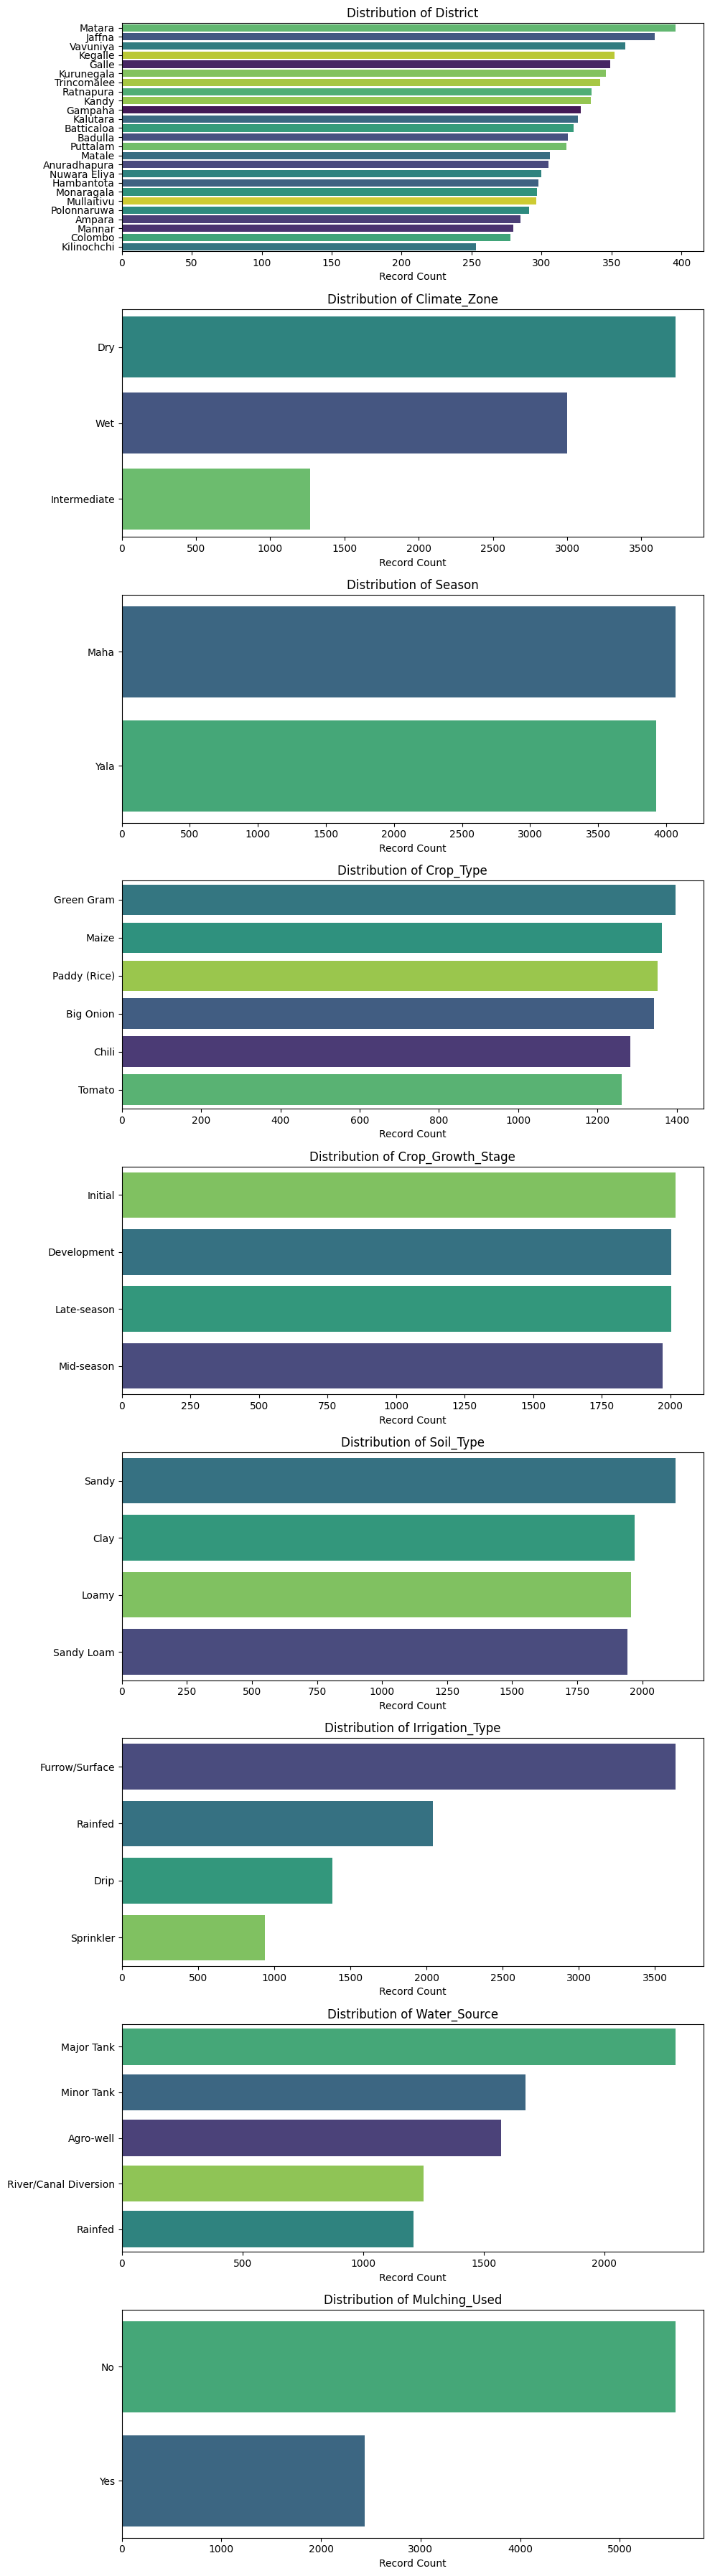

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a grid for your categorical plots
num_cols = len(qual)
fig, axes = plt.subplots(nrows=num_cols, ncols=1, figsize=(10, 4 * num_cols))

# If there is only 1 categorical column, convert axes to an array to prevent errors
if num_cols == 1:
    axes = [axes]

# Plot a countplot for each categorical feature
for i, col in enumerate(qual):
    # Added hue=col and legend=False to fix the deprecation warning
    sns.countplot(
        data=X_train, 
        y=col, 
        ax=axes[i], 
        order=X_train[col].value_counts().index, 
        palette="viridis",
        hue=col,
        legend=False
    )
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel("Record Count")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

In [20]:
X_train_clean=X_train.copy()
X_test_clean=X_test.copy()

In [21]:
from sklearn.preprocessing import OneHotEncoder

X_train_encoded = X_train_clean.copy()
X_test_encoded  = X_test_clean.copy()

# here we find the categorical features as bianry and multiple class in X_train_encoded
#====================================================================================
text_columns = [
    col for col in X_train_encoded.select_dtypes(include=['object', 'category']).columns 
    if not col.endswith('_is_missing')
]

binary_cols = [col for col in text_columns if X_train_encoded[col].nunique() <= 2]
multiclass_cols = [col for col in text_columns if X_train_encoded[col].nunique() > 2]

print("=== Encoding Feature Categorization ===")
print(f"🔹 Binary features mapped ({len(binary_cols)})")
print(f"🔹 Multi-class features mapped ({len(multiclass_cols)})\n")
# ====================================================================================


# encoding our binary categorical features
# ====================================================================================
if binary_cols:
    for col in binary_cols:
        # Cast to standard string arrays and read the unique elements present in the training set
        train_categories = X_train_encoded[col].astype(str).unique()
        
        # Build an explicit, clean 0/1 integer index mapping dictionary layout
        binary_map = {category_name: index for index, category_name in enumerate(train_categories[:2])}
        
        # Apply mapping across columns simultaneously via native vectorized math.
        # Unknown values in test split are safely caught using .fillna(0) to prevent rogue negative coordinates
        X_train_encoded[col] = X_train_encoded[col].astype(str).map(binary_map).fillna(0).astype(int)
        X_test_encoded[col]  = X_test_encoded[col].astype(str).map(binary_map).fillna(0).astype(int)
# ====================================================================================


# Here we are encoding the multi class categorical columns
# ====================================================================================
if multiclass_cols:
    # Initialize encoder. handle_unknown='ignore' ensures any brand-new unseen test categories are silently dropped
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=int)
    
    # Fit on training data and transform arrays via C-speed matrix operations
    train_ohe_array = ohe.fit_transform(X_train_encoded[multiclass_cols].astype(str))
    test_ohe_array  = ohe.transform(X_test_encoded[multiclass_cols].astype(str))
    
    # Generate human-readable new feature names (e.g., 'feature_category')
    new_column_names = ohe.get_feature_names_out(multiclass_cols)
    
    # Package matrices back into beautifully structured dataframes, keeping original index numbers aligned
    train_ohe_df = pd.DataFrame(train_ohe_array, columns=new_column_names, index=X_train_encoded.index)
    test_ohe_df  = pd.DataFrame(test_ohe_array,  columns=new_column_names, index=X_test_encoded.index)
    
    # Clean drop old original text string variables and append the newly created binary dummy columns
    X_train_encoded = pd.concat([X_train_encoded.drop(columns=multiclass_cols), train_ohe_df], axis=1)
    X_test_encoded  = pd.concat([X_test_encoded.drop(columns=multiclass_cols),  test_ohe_df],  axis=1)
# ====================================================================================

=== Encoding Feature Categorization ===
🔹 Binary features mapped (2)
🔹 Multi-class features mapped (7)



In [22]:
X_train_encoded.head()

,Season,Stage_Duration_days,Soil_pH,Soil_Moisture_pct,Organic_Carbon_pct,Electrical_Conductivity_dSm,Tmax_C,Tmin_C,Temperature_C,Humidity_pct,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Mulching_Used,Reference_ET0_mm_day,Crop_Coefficient_Kc,District_Ampara,District_Anuradhapura,District_Badulla,District_Batticaloa,District_Colombo,District_Galle,District_Gampaha,District_Hambantota,District_Jaffna,District_Kalutara,District_Kandy,District_Kegalle,District_Kilinochchi,District_Kurunegala,District_Mannar,District_Matale,District_Matara,District_Monaragala,District_Mullaitivu,District_Nuwara Eliya,District_Polonnaruwa,District_Puttalam,District_Ratnapura,District_Trincomalee,District_Vavuniya,Climate_Zone_Dry,Climate_Zone_Intermediate,Climate_Zone_Wet,Crop_Type_Big Onion,Crop_Type_Chili,Crop_Type_Green Gram,Crop_Type_Maize,Crop_Type_Paddy (Rice),Crop_Type_Tomato,Crop_Growth_Stage_Development,Crop_Growth_Stage_Initial,Crop_Growth_Stage_Late-season,Crop_Growth_Stage_Mid-season,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Sandy,Soil_Type_Sandy Loam,Irrigation_Type_Drip,Irrigation_Type_Furrow/Surface,Irrigation_Type_Rainfed,Irrigation_Type_Sprinkler,Water_Source_Agro-well,Water_Source_Major Tank,Water_Source_Minor Tank,Water_Source_Rainfed,Water_Source_River/Canal Diversion
9254,0,60,5.57,18.90,0.82,0.84,28.8,23.6,26.2,76.6,353.8,7.5,5.2,0.47,0,3.06,1.05,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,1,0,0,0,0
1561,0,25,5.09,10.41,0.77,0.54,28.8,20.9,24.8,75.6,206.1,5.5,7.3,0.49,1,4.07,0.90,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0
1670,1,35,5.07,5.70,0.68,0.37,33.9,24.4,29.2,78.4,53.7,7.4,16.4,0.46,1,5.00,1.05,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0
6087,1,30,5.90,12.39,0.62,0.35,35.0,24.8,29.9,69.0,0.0,7.3,16.1,2.27,0,5.33,0.90,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,0
6669,1,18,5.28,11.79,0.91,0.26,35.1,24.2,29.7,75.3,46.8,8.4,11.7,0.10,1,5.51,0.75,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0


In [23]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the StandardScaler instance
scaler = StandardScaler()

# 2. FIT & TRANSFORM: Training split conversion
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_encoded), 
    columns=X_train_encoded.columns, 
    index=X_train_encoded.index
)

# 3. TRANSFORM ONLY: Test split conversion (Prevents Data Leakage)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_encoded), 
    columns=X_test_encoded.columns, 
    index=X_test_encoded.index
)

In [24]:
X_train_scaled.head()

,Season,Stage_Duration_days,Soil_pH,Soil_Moisture_pct,Organic_Carbon_pct,Electrical_Conductivity_dSm,Tmax_C,Tmin_C,Temperature_C,Humidity_pct,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Mulching_Used,Reference_ET0_mm_day,Crop_Coefficient_Kc,District_Ampara,District_Anuradhapura,District_Badulla,District_Batticaloa,District_Colombo,District_Galle,District_Gampaha,District_Hambantota,District_Jaffna,District_Kalutara,District_Kandy,District_Kegalle,District_Kilinochchi,District_Kurunegala,District_Mannar,District_Matale,District_Matara,District_Monaragala,District_Mullaitivu,District_Nuwara Eliya,District_Polonnaruwa,District_Puttalam,District_Ratnapura,District_Trincomalee,District_Vavuniya,Climate_Zone_Dry,Climate_Zone_Intermediate,Climate_Zone_Wet,Crop_Type_Big Onion,Crop_Type_Chili,Crop_Type_Green Gram,Crop_Type_Maize,Crop_Type_Paddy (Rice),Crop_Type_Tomato,Crop_Growth_Stage_Development,Crop_Growth_Stage_Initial,Crop_Growth_Stage_Late-season,Crop_Growth_Stage_Mid-season,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Sandy,Soil_Type_Sandy Loam,Irrigation_Type_Drip,Irrigation_Type_Furrow/Surface,Irrigation_Type_Rainfed,Irrigation_Type_Sprinkler,Water_Source_Agro-well,Water_Source_Major Tank,Water_Source_Minor Tank,Water_Source_Rainfed,Water_Source_River/Canal Diversion
9254,-0.982159,3.314890,-0.314722,0.080211,-0.478782,0.951109,-0.791581,0.574919,-0.307724,-0.093100,1.960263,0.512068,-1.310545,-0.739101,-1.510869,-1.438261,0.867066,-0.192200,-0.199088,-0.203792,-0.205119,-0.189739,-0.213577,4.836346,-0.196701,-0.223621,-0.206109,-0.209058,-0.214535,-0.180715,-0.212615,-0.190445,-0.199427,-0.228206,-0.196358,-0.196014,-0.197386,-0.194289,-0.203459,-0.209383,-0.211327,-0.217072,-0.935101,-0.433998,1.290994,-0.449158,2.287035,-0.460167,-0.452971,-0.450965,-0.432573,-0.578120,-0.581199,-0.577928,1.747781,-0.571769,-0.568882,-0.602188,1.765000,-0.456573,1.095269,-0.585626,-0.36489,2.022943,-0.634448,-0.514220,-0.422141,-0.430331
1561,-0.982159,-0.079241,-1.110269,-0.945080,-0.600368,-0.106943,-0.791581,-1.140618,-1.135138,-0.223610,0.664010,-1.251061,-0.667118,-0.711072,0.661871,-0.163014,0.275010,-0.192200,-0.199088,-0.203792,-0.205119,-0.189739,4.682161,-0.206768,-0.196701,-0.223621,-0.206109,-0.209058,-0.214535,-0.180715,-0.212615,-0.190445,-0.199427,-0.228206,-0.196358,-0.196014,-0.197386,-0.194289,-0.203459,-0.209383,-0.211327,-0.217072,-0.935101,-0.433998,1.290994,2.226390,-0.437247,-0.460167,-0.452971,-0.450965,-0.432573,1.729744,-0.581199,-0.577928,-0.572154,-0.571769,-0.568882,1.660612,-0.566572,-0.456573,-0.913017,1.707574,-0.36489,-0.494329,-0.634448,1.944693,-0.422141,-0.430331
1670,1.018165,0.890511,-1.143417,-1.513881,-0.819223,-0.706505,1.282191,1.083227,1.465306,0.141819,-0.673492,0.423911,2.121063,-0.753116,0.661871,1.011223,0.867066,-0.192200,-0.199088,-0.203792,-0.205119,-0.189739,-0.213577,-0.206768,-0.196701,-0.223621,-0.206109,-0.209058,-0.214535,-0.180715,-0.212615,5.250850,-0.199427,-0.228206,-0.196358,-0.196014,-0.197386,-0.194289,-0.203459,-0.209383,-0.211327,-0.217072,1.069403,-0.433998,-0.774597,2.226390,-0.437247,-0.460167,-0.452971,-0.450965,-0.432573,-0.578120,-0.581199,-0.577928,1.747781,-0.571769,-0.568882,1.660612,-0.566572,2.190229,-0.913017,-0.585626,-0.36489,-0.494329,-0.634448,-0.514220,2.368875,-0.430331
6087,1.018165,0.405635,0.232217,-0.705966,-0.965126,-0.777042,1.729475,1.337380,1.879013,-1.084981,-1.144777,0.335755,2.029145,1.783566,-1.510869,1.427888,0.275010,5.202901,-0.199088,-0.203792,-0.205119,-0.189739,-0.213577,-0.206768,-0.196701,-0.223621,-0.206109,-0.209058,-0.214535,-0.180715,-0.212615,-0.190445,-0.199427,-0.228206,-0.196358,-0.196014,-0.197386,-0.194289,-0.203459,-0.209383,-0.211327,-0.217072,1.069403,-0.433998,-0.774597,-0.449158,2.287035,-0.460167,-0.452971,-0.450965,-0.432573,-0.578120,-0.581199,1.730320,-0.572154,-0.571769,-0.568882,-0.602188,1.765000,-0.456573,-0.913017,1.707574,-0.36489,-0.494329,1.576173,-0.514220,-0.422141,-0.430331
6669,1.018165,-0.758067

In [25]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Initialize the baseline regressor (always predicts the mean target value)
dummy_reg = DummyRegressor(strategy='mean')
dummy_reg.fit(X_train, y_train)

# 2. Predict on the test set
y_dummy_pred = dummy_reg.predict(X_test)

# 3. Evaluate the benchmark
print("=== Baseline (DummyRegressor — Mean Target Value) ===")
print(f"MAE      : {mean_absolute_error(y_test, y_dummy_pred):.2f} mm")
print(f"R² Score : {r2_score(y_test, y_dummy_pred):.4f}")
print("\nAny real model MUST achieve a LOWER MAE and a HIGHER R² score than this baseline.")

=== Baseline (DummyRegressor — Mean Target Value) ===
MAE      : 29.69 mm
R² Score : -0.0012

Any real model MUST achieve a LOWER MAE and a HIGHER R² score than this baseline.


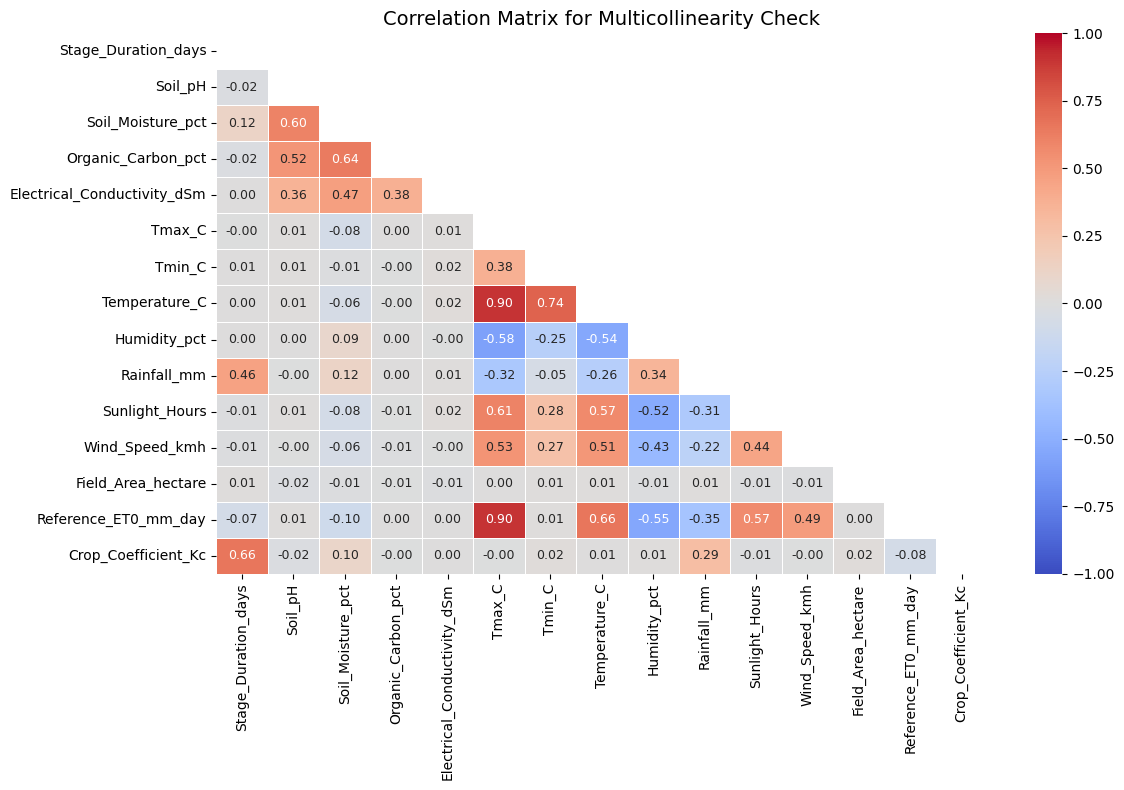


--- Variance Inflation Factor (VIF) Scores ---
                        Feature          VIF
0                 Temperature_C  2272.630393
1                        Tmax_C  1215.245906
2                        Tmin_C   496.732538
3          Reference_ET0_mm_day    18.721429
4             Soil_Moisture_pct     2.353208
5           Stage_Duration_days     2.186428
6            Organic_Carbon_pct     1.817355
7                Sunlight_Hours     1.804633
8           Crop_Coefficient_Kc     1.803363
9                  Humidity_pct     1.764138
10                      Soil_pH     1.693864
11                  Rainfall_mm     1.585793
12               Wind_Speed_kmh     1.502825
13  Electrical_Conductivity_dSm     1.322912
14           Field_Area_hectare     1.002357


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Ensure we ONLY check multicollinearity on numerical features
# (Using encoded categorical variables will break VIF or cause infinite scores)
X_train_numerical = X_train_scaled[quan]

# ==========================================
# 2. METHOD A: VISUAL CORRELATION HEATMAP
# ==========================================
plt.figure(figsize=(12, 8))
corr_matrix = X_train_numerical.corr()

# Create a mask to hide the upper triangle to remove visual clutter
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Matrix for Multicollinearity Check', fontsize=14)
plt.tight_layout()
plt.show()

# ==========================================
# 3. METHOD B: STATISTICAL VARIANCE INFLATION FACTOR (VIF)
# ==========================================
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_numerical.columns

# Calculate VIF score safely for each numerical feature
vif_data["VIF"] = [
    variance_inflation_factor(X_train_numerical.values, i) 
    for i in range(X_train_numerical.shape[1])
]

# Sort features by VIF score in descending order
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print("\n--- Variance Inflation Factor (VIF) Scores ---")
print(vif_data)

--- Top 10 Most Important Features ---
                 Feature  Importance
0    Crop_Coefficient_Kc    0.266773
1            Rainfall_mm    0.237906
2          Temperature_C    0.173488
3    Stage_Duration_days    0.147488
4   Reference_ET0_mm_day    0.043237
5                 Tmax_C    0.041560
6           Humidity_pct    0.011537
7                 Season    0.011123
8        Crop_Type_Chili    0.011066
9      Soil_Moisture_pct    0.008116
10        Sunlight_Hours    0.004787
11    Organic_Carbon_pct    0.004301


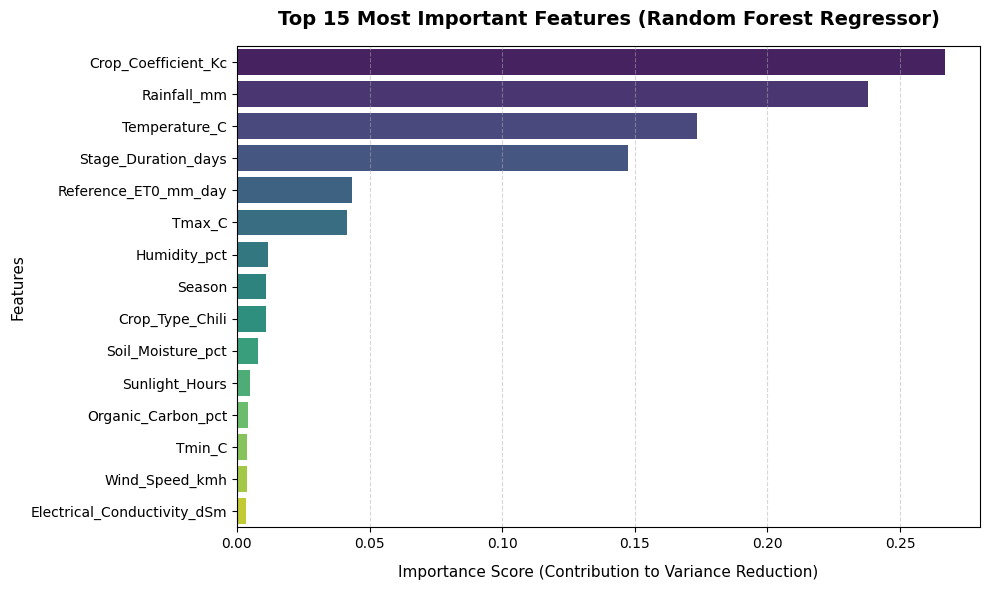

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

# 1. INITIALIZE AND TRAIN THE MODEL 
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# 2. EXTRACT SCORES AND PAIR THEM WITH COLUMN NAMES
importance_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("--- Top 10 Most Important Features ---")
print(importance_df.head(12))

# =====================================================================
# 3. PLOT THE TOP 10 FEATURE IMPORTANCE (Optimized for a Clean Output)
# =====================================================================
# Select only the top 10 rows to prevent the chart from becoming overcrowded
top_10_importance = importance_df.head(15)

# Set a wider, cleaner figure size optimized for 10 bars
plt.figure(figsize=(10, 6))

# Generate the barplot using only the top 10 features
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=top_10_importance, 
    palette='viridis',
    hue='Feature',
    legend=False
)

# Add clean labels, a larger title, and clear gridlines for readability
plt.title('Top 15 Most Important Features (Random Forest Regressor)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance Score (Contribution to Variance Reduction)', fontsize=11, labelpad=10)
plt.ylabel('Features', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5) # Adds a soft background grid for easier tracking

plt.tight_layout()
plt.show()

In [28]:
X_train_final = X_train_scaled.drop(columns=['Temperature_C', 'Tmax_C'])

# 2. Mirror the exact same step on the testing data
X_test_final = X_test_scaled.drop(columns=['Temperature_C', 'Tmax_C'])

# --- Quick verification check ---
print(f"Cleaned Data Shapes -> Train: {X_train_final.shape} | Test: {X_test_final.shape}")

Cleaned Data Shapes -> Train: (8000, 66) | Test: (2000, 66)


In [29]:
X_train_final

,Season,Stage_Duration_days,Soil_pH,Soil_Moisture_pct,Organic_Carbon_pct,Electrical_Conductivity_dSm,Tmin_C,Humidity_pct,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Mulching_Used,Reference_ET0_mm_day,Crop_Coefficient_Kc,District_Ampara,District_Anuradhapura,District_Badulla,District_Batticaloa,District_Colombo,District_Galle,District_Gampaha,District_Hambantota,District_Jaffna,District_Kalutara,District_Kandy,District_Kegalle,District_Kilinochchi,District_Kurunegala,District_Mannar,District_Matale,District_Matara,District_Monaragala,District_Mullaitivu,District_Nuwara Eliya,District_Polonnaruwa,District_Puttalam,District_Ratnapura,District_Trincomalee,District_Vavuniya,Climate_Zone_Dry,Climate_Zone_Intermediate,Climate_Zone_Wet,Crop_Type_Big Onion,Crop_Type_Chili,Crop_Type_Green Gram,Crop_Type_Maize,Crop_Type_Paddy (Rice),Crop_Type_Tomato,Crop_Growth_Stage_Development,Crop_Growth_Stage_Initial,Crop_Growth_Stage_Late-season,Crop_Growth_Stage_Mid-season,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Sandy,Soil_Type_Sandy Loam,Irrigation_Type_Drip,Irrigation_Type_Furrow/Surface,Irrigation_Type_Rainfed,Irrigation_Type_Sprinkler,Water_Source_Agro-well,Water_Source_Major Tank,Water_Source_Minor Tank,Water_Source_Rainfed,Water_Source_River/Canal Diversion
9254,-0.982159,3.314890,-0.314722,0.080211,-0.478782,0.951109,0.574919,-0.093100,1.960263,0.512068,-1.310545,-0.739101,-1.510869,-1.438261,0.867066,-0.192200,-0.199088,-0.203792,-0.205119,-0.189739,-0.213577,4.836346,-0.196701,-0.223621,-0.206109,-0.209058,-0.214535,-0.180715,-0.212615,-0.190445,-0.199427,-0.228206,-0.196358,-0.196014,-0.197386,-0.194289,-0.203459,-0.209383,-0.211327,-0.217072,-0.935101,-0.433998,1.290994,-0.449158,2.287035,-0.460167,-0.452971,-0.450965,-0.432573,-0.578120,-0.581199,-0.577928,1.747781,-0.571769,-0.568882,-0.602188,1.765000,-0.456573,1.095269,-0.585626,-0.36489,2.022943,-0.634448,-0.514220,-0.422141,-0.430331
1561,-0.982159,-0.079241,-1.110269,-0.945080,-0.600368,-0.106943,-1.140618,-0.223610,0.664010,-1.251061,-0.667118,-0.711072,0.661871,-0.163014,0.275010,-0.192200,-0.199088,-0.203792,-0.205119,-0.189739,4.682161,-0.206768,-0.196701,-0.223621,-0.206109,-0.209058,-0.214535,-0.180715,-0.212615,-0.190445,-0.199427,-0.228206,-0.196358,-0.196014,-0.197386,-0.194289,-0.203459,-0.209383,-0.211327,-0.217072,-0.935101,-0.433998,1.290994,2.226390,-0.437247,-0.460167,-0.452971,-0.450965,-0.432573,1.729744,-0.581199,-0.577928,-0.572154,-0.571769,-0.568882,1.660612,-0.566572,-0.456573,-0.913017,1.707574,-0.36489,-0.494329,-0.634448,1.944693,-0.422141,-0.430331
1670,1.018165,0.890511,-1.143417,-1.513881,-0.819223,-0.706505,1.083227,0.141819,-0.673492,0.423911,2.121063,-0.753116,0.661871,1.011223,0.867066,-0.192200,-0.199088,-0.203792,-0.205119,-0.189739,-0.213577,-0.206768,-0.196701,-0.223621,-0.206109,-0.209058,-0.214535,-0.180715,-0.212615,5.250850,-0.199427,-0.228206,-0.196358,-0.196014,-0.197386,-0.194289,-0.203459,-0.209383,-0.211327,-0.217072,1.069403,-0.433998,-0.774597,2.226390,-0.437247,-0.460167,-0.452971,-0.450965,-0.432573,-0.578120,-0.581199,-0.577928,1.747781,-0.571769,-0.568882,1.660612,-0.566572,2.190229,-0.913017,-0.585626,-0.36489,-0.494329,-0.634448,-0.514220,2.368875,-0.430331
6087,1.018165,0.405635,0.232217,-0.705966,-0.965126,-0.777042,1.337380,-1.084981,-1.144777,0.335755,2.029145,1.783566,-1.510869,1.427888,0.275010,5.202901,-0.199088,-0.203792,-0.205119,-0.189739,-0.213577,-0.206768,-0.196701,-0.223621,-0.206109,-0.209058,-0.214535,-0.180715,-0.212615,-0.190445,-0.199427,-0.228206,-0.196358,-0.196014,-0.197386,-0.194289,-0.203459,-0.209383,-0.211327,-0.217072,1.069403,-0.433998,-0.774597,-0.449158,2.287035,-0.460167,-0.452971,-0.450965,-0.432573,-0.578120,-0.581199,1.730320,-0.572154,-0.571769,-0.568882,-0.602188,1.765000,-0.456573,-0.913017,1.707574,-0.36489,-0.494329,1.576173,-0.514220,-0.422141,-0.430331
6669,1.018165,-0.758067,-0.795365,-0.778425,-0.259927,-1.094458,0.956150,-0.262764,-0.734048,1.305476,0.681013,-1.257650

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesRegressor # CHANGED: Fast, compatible alternative
from sklearn.feature_selection import RFECV
from sklearn.model_selection import KFold

# 1. Initialize a fast tree estimator and continuous CV strategy
# ExtraTreesRegressor uses random splits to run much faster than a standard Random Forest
fast_estimator = ExtraTreesRegressor(n_estimators=50, random_state=42, n_jobs=-1)
cv_strategy    = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Fit RFECV using Negative MAE Scoring
# Dropping 5 features at a time (step=5) to speed up execution
rfecv = RFECV(
    estimator=fast_estimator, 
    step=5, 
    cv=cv_strategy, 
    scoring='neg_mean_absolute_error', 
    n_jobs=-1
)
rfecv.fit(X_train_final, y_train)

# 3. Extract optimal indices
optimal_n      = rfecv.n_features_
selected_feats = X_train_final.columns[rfecv.support_].tolist()

print("--- RFE Selection Summary ---")
print(f"Original number of features : {X_train_final.shape[1]}")
print(f"Number of selected features  : {optimal_n}")

print("\n✅ SELECTED FEATURES:")
print(selected_feats)
print()

--- RFE Selection Summary ---
Original number of features : 66
Number of selected features  : 16

✅ SELECTED FEATURES:
['Season', 'Stage_Duration_days', 'Soil_Moisture_pct', 'Humidity_pct', 'Rainfall_mm', 'Sunlight_Hours', 'Mulching_Used', 'Reference_ET0_mm_day', 'Crop_Coefficient_Kc', 'Climate_Zone_Dry', 'Climate_Zone_Wet', 'Crop_Type_Chili', 'Crop_Type_Green Gram', 'Crop_Type_Paddy (Rice)', 'Crop_Growth_Stage_Development', 'Crop_Growth_Stage_Mid-season']



In [34]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# 1. CRITICAL FIX: Filter BOTH train and test sets to maintain shape alignment
X_train_pre = X_train_final[selected_feats]
X_test_pre  = X_test_final[selected_feats]  # Added: Prevents ValueError at prediction time

# 2. Re-fit your TRUE production model architecture on the filtered features
# (We use the regressor now that we've cleared out the fast selection proxies)
production_engine = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
production_engine.fit(X_train_pre, y_train)

# 3. Extract and sort the actual mathematical importances based on variance reduction
rankings = pd.Series(production_engine.feature_importances_, index=X_train_pre.columns)
limited_features = rankings.nlargest(5).index.tolist()

print("--- 🌾 True Random Forest Regressor Rankings ---")
print(rankings.sort_values(ascending=False))

print(f"\n✅ Use these 5 features for your cost-effective deployment pipeline:\n{limited_features}")


--- 🌾 True Random Forest Regressor Rankings ---
Rainfall_mm                      0.248564
Stage_Duration_days              0.245849
Crop_Coefficient_Kc              0.205924
Reference_ET0_mm_day             0.204877
Season                           0.021225
Crop_Growth_Stage_Mid-season     0.019299
Humidity_pct                     0.016191
Soil_Moisture_pct                0.012962
Crop_Type_Chili                  0.008204
Sunlight_Hours                   0.007041
Crop_Growth_Stage_Development    0.003185
Crop_Type_Paddy (Rice)           0.002055
Mulching_Used                    0.002005
Climate_Zone_Dry                 0.001010
Climate_Zone_Wet                 0.000859
Crop_Type_Green Gram             0.000751
dtype: float64

✅ Use these 5 features for your cost-effective deployment pipeline:
['Rainfall_mm', 'Stage_Duration_days', 'Crop_Coefficient_Kc', 'Reference_ET0_mm_day', 'Season']


In [35]:
limited_features

['Rainfall_mm',
 'Stage_Duration_days',
 'Crop_Coefficient_Kc',
 'Reference_ET0_mm_day',
 'Season']

In [36]:
# The elite, dynamic pandas execution way
X_train_selected = X_train_final[limited_features]
X_test_selected  = X_test_final[limited_features]

print(f"\nFinal Ready Shapes ➔ Train: {X_train_selected.shape} | Test: {X_test_selected.shape}\n")


Final Ready Shapes ➔ Train: (8000, 5) | Test: (2000, 5)



In [37]:
print("--- Features Matrix Columns Verification ---")
print(list(X_train_selected.columns))
print()

--- Features Matrix Columns Verification ---
['Rainfall_mm', 'Stage_Duration_days', 'Crop_Coefficient_Kc', 'Reference_ET0_mm_day', 'Season']



In [48]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Continuous cross-validation setup (No stratification on floats!)
cv5 = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Rebuilt Model Suite for Continuous Net Irrigation Predictions
REGRESSION_MODELS = {
    "Linear Regression":  LinearRegression(),
    "Ridge Regression":   Ridge(alpha=1.0, random_state=42),
    "KNN Regressor":       KNeighborsRegressor(n_neighbors=5),
    "SVM Regressor (RBF)": SVR(kernel="rbf", C=1.0),
    "Decision Tree":       DecisionTreeRegressor(random_state=42),
    "Random Forest":       RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingRegressor(random_state=42, n_estimators=100),
}

results = []
for name, model in REGRESSION_MODELS.items():
    
    # 3. Step A: Cross-Validation using Negative MAE on your SELECTED 5-feature training matrix
    # FIXED: Replaced X_train_pre with X_train_selected
    cv_scores = cross_val_score(model, X_train_selected, y_train, cv=cv5, scoring='neg_mean_absolute_error', n_jobs=-1)
    mean_cv_mae = -cv_scores.mean()
    
    # 4. Step B: Train ONCE on full 5-feature training data to predict on the 5-feature test set
    # FIXED: Replaced X_train_pre/X_test_pre with X_train_selected/X_test_selected
    model.fit(X_train_selected, y_train)
    y_pred = model.predict(X_test_selected)
    
    # 5. Calculate exact performance metrics
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    
    # 6. Collect all metrics for this model row
    results.append({
        "Model": name,
        "CV MAE (Train)": mean_cv_mae, 
        "Test MAE (mm)":  mae,
        "Test RMSE (mm)": rmse,
        "Test R² Score":  r2
    })

# 7. Turn into a DataFrame and rank by the lowest Cross-Validation error
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by="CV MAE (Train)", ascending=True).reset_index(drop=True)

# 8. Format the final output table for clean presentation
df_results["CV MAE (Train)"] = df_results["CV MAE (Train)"].map(lambda x: f"{x:.2f} mm")
df_results["Test MAE (mm)"]  = df_results["Test MAE (mm)"].map(lambda x: f"{x:.2f} mm")
df_results["Test RMSE (mm)"] = df_results["Test RMSE (mm)"].map(lambda x: f"{x:.2f} mm")
df_results["Test R² Score"]  = df_results["Test R² Score"].map(lambda x: f"{x:.4f}")

print("\n📊 PRODUCTION MODEL BENCHMARK TABLE (Ranked by Lowest CV MAE)")
print("="*85)
display(df_results)


📊 PRODUCTION MODEL BENCHMARK TABLE (Ranked by Lowest CV MAE)


,Model,CV MAE (Train),Test MAE (mm),Test RMSE (mm),Test R² Score
0,Random Forest,4.48 mm,4.46 mm,9.04 mm,0.9531
1,KNN Regressor,4.82 mm,4.80 mm,9.81 mm,0.9448
2,Decision Tree,5.78 mm,5.92 mm,12.34 mm,0.9125
3,Gradient Boosting,6.02 mm,6.10 mm,9.91 mm,0.9435
4,SVM Regressor (RBF),8.30 mm,8.15 mm,16.41 mm,0.8454
5,Ridge Regression,18.44 mm,18.68 mm,24.91 mm,0.6436
6,Linear Regression,18.44 mm,18.68 mm,24.91 mm,0.6436


In [50]:
import pandas as pd
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor

# 1. FIXED: Hyperparameter Grid completely populated with explicit list arrays
param_grid = {
    'n_estimators': [50, 100, 150],      
    'min_samples_split': [2, 5],         
    'min_samples_leaf': [1, 2]             
}

# 2. Continuous cross-validation setup (No stratification on floats!)
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. Set up Grid Search for your winning Random Forest Regressor engine
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='neg_mean_absolute_error', # Optimizing to find the absolute lowest millimeter error
    n_jobs=-1
)

# 4. Fit using your filtered production features (X_train_pre)
grid_search.fit(X_train_selected, y_train)
best_rf_model = grid_search.best_estimator_

print("--- 🎯 Hyperparameter Tuning Summary ---")
print(f"Best RF Parameters : {grid_search.best_params_}")
# Convert negative MAE back to positive for intuitive reading
print(f"Best CV MAE        : {-grid_search.best_score_:.2f} mm")

--- 🎯 Hyperparameter Tuning Summary ---
Best RF Parameters : {'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 150}
Best CV MAE        : 4.43 mm


🏆 FINAL TUNED REGRESSION MODEL REPORT
Final Mean Absolute Error (MAE) : 4.38 mm
Final Root Mean Squared Error   : 8.98 mm
Final R² Score (Variance Match) : 0.9536


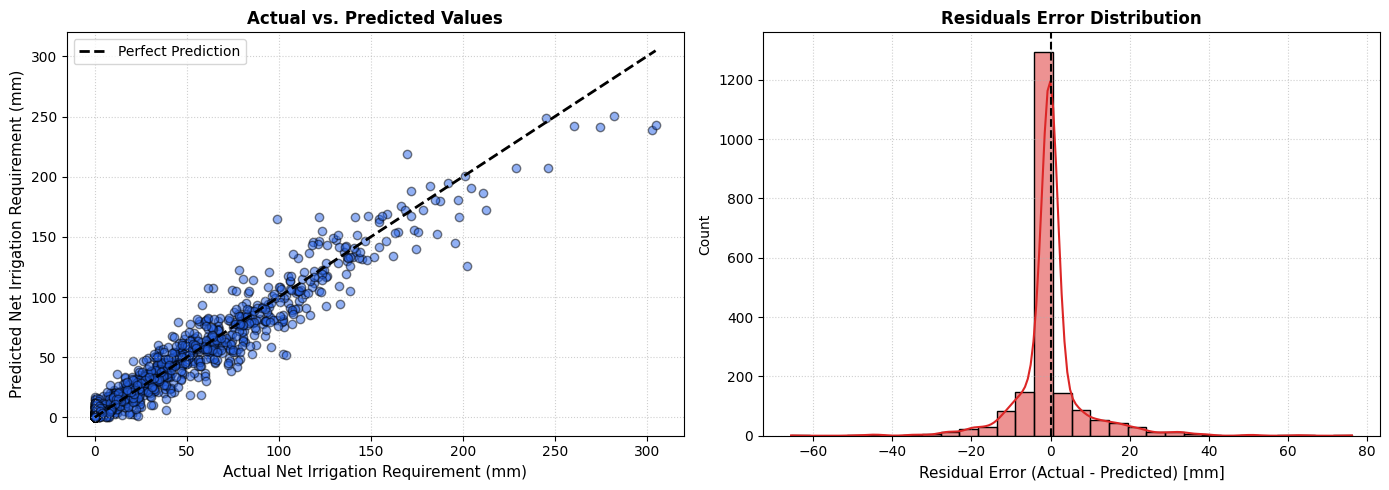

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. FIXED: Predict on your SELECTED test features to match y_test sample sizes
y_pred = best_rf_model.predict(X_test_selected)

# 2. Calculate Final Performance Metrics on Unseen Test Data
final_mae = mean_absolute_error(y_test, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_r2 = r2_score(y_test, y_pred)

print("🏆 FINAL TUNED REGRESSION MODEL REPORT")
print("=" * 55)
print(f"Final Mean Absolute Error (MAE) : {final_mae:.2f} mm")
print(f"Final Root Mean Squared Error   : {final_rmse:.2f} mm")
print(f"Final R² Score (Variance Match) : {final_r2:.4f}")
print("=" * 55)

# 3. Structural Evaluation Graphics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Prediction vs Actuals (Ideally a tight diagonal 45-degree line)
axes[0].scatter(y_test, y_pred, alpha=0.5, color='#2563EB', edgecolors='k')
ideal_line = [min(y_test), max(y_test)]
axes[0].plot(ideal_line, ideal_line, 'k--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Net Irrigation Requirement (mm)', fontsize=11)
axes[0].set_ylabel('Predicted Net Irrigation Requirement (mm)', fontsize=11)
axes[0].set_title('Actual vs. Predicted Values', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# Plot B: Residuals Distribution (Checks if errors are normally distributed around 0)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='#DC2626', ax=axes[1], bins=30)
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual Error (Actual - Predicted) [mm]', fontsize=11)
axes[1].set_title('Residuals Error Distribution', fontsize=12, fontweight='bold')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


In [53]:
import pandas as pd

# 1. Extract the true mathematical feature importances from your tuned model
importances = best_rf_model.feature_importances_

# 2. FIXED: Aligned feature names to X_train_pre and renamed the dataframe professionally
irrigation_importance_df = pd.DataFrame({
    'Feature': X_test_selected.columns,
    'Importance Score': importances,
    'Contribution': ['High Impact' if imp > 0.10 else 'Moderate/Low Impact' for imp in importances]
}).sort_values('Importance Score', ascending=False).reset_index(drop=True)

print("🌾 IRRIGATION FEATURE IMPORTANCE RANKING")
print("="*55)
display(irrigation_importance_df)

🌾 IRRIGATION FEATURE IMPORTANCE RANKING


,Feature,Importance Score,Contribution
0,Stage_Duration_days,0.276614,High Impact
1,Rainfall_mm,0.264717,High Impact
2,Crop_Coefficient_Kc,0.220994,High Impact
3,Reference_ET0_mm_day,0.217248,High Impact
4,Season,0.020426,Moderate/Low Impact


In [55]:
import os
import joblib

# 1. FIXED: Exporting the model, the feature schema, AND the vital scaler instance
joblib.dump(best_rf_model, 'sri_lanka_irrigation_model.joblib')
joblib.dump(scaler, 'irrigation_scaler.joblib') # Added: Keeps deployment inputs properly scaled
joblib.dump(limited_features, 'selected_features.joblib') 

# 2. Physical File Integrity Logs
asset_files = ['sri_lanka_irrigation_model.joblib', 'irrigation_scaler.joblib', 'selected_features.joblib']
print("📦 EXPORTING ALL 3 PRODUCTION ARTIFACTS...")
print("=" * 65)

for file_name in asset_files:
    if os.path.exists(file_name):
        size_kb = os.path.getsize(file_name) / 1024
        print(f"  • File Name: '{file_name:<32}' | File Size: {size_kb:.2f} KB")
    else:
        print(f"  🚨 ERROR: Failed to serialize file: '{file_name}'")
print("=" * 65)
print("✅ Done! All 3 files verified. Your deployment app is now structurally safe.")

📦 EXPORTING ALL 3 PRODUCTION ARTIFACTS...
  • File Name: 'sri_lanka_irrigation_model.joblib' | File Size: 18805.13 KB
  • File Name: 'irrigation_scaler.joblib        ' | File Size: 3.83 KB
  • File Name: 'selected_features.joblib        ' | File Size: 0.10 KB
✅ Done! All 3 files verified. Your deployment app is now structurally safe.


In [59]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import joblib

# Suppress scikit-learn's 1D array warning noise globally
warnings.filterwarnings('ignore', category=UserWarning, append=True)

def run_pre_deployment_checks(model_path, scaler_path, sample_X, sample_y):
    print("=" * 65)
    print("🌊 PRODUCTION-GRADE AGRICULTURAL MODEL INTEGRITY AUDIT")
    print("=" * 65)

    print("\n1. File existence check...")
    if os.path.exists(model_path) and os.path.exists(scaler_path):
        print(f"  [PASS] Both production model and scaler files found.")
    else:
        print("  [FAIL] Missing model or scaler asset files!"); return

    print("\n2. Loading check...")
    try:
        deployed_scaler = joblib.load(scaler_path)
        deployed_model = joblib.load(model_path)
        print("  [PASS] Model and Scaler successfully loaded into memory.")
    except Exception as e:
        print(f"  [FAIL] Deserialization failed: {e}"); return

    # =====================================================================
    # 3. FIXED: INTEGRATED PREDICTION LATENCY & BASELINE ALIGNMENT CHECK
    # =====================================================================
    print("\n3. Prediction latency check...")
    batch = sample_X.head(5)
    
    # FRESH BASELINE: Generate a live prediction in the notebook right now
    notebook_baseline_preds = best_rf_model.predict(batch)
    
    t0    = time.time()
    deployed_file_preds = deployed_model.predict(batch)
    ms    = (time.time() - t0) * 1000
    print(f"  [PASS] Prediction Latency: {ms:.2f} ms")
    
    # Check if the loaded file matches the active notebook model exactly
    if np.allclose(deployed_file_preds, notebook_baseline_preds, atol=1e-5):
        print("  [PASS] Saved model file output matches active notebook baseline exactly.")
    else:
        print(f"  [WARN] Prediction mismatch! The saved file does not match the active model instance."); return

    print("\n4. End-to-End Edge-Case Pipeline Stress Test...")
    try:
        all_original_features = list(deployed_scaler.feature_names_in_)
        extreme_field = pd.DataFrame([{col: 0.0 for col in all_original_features}])
        
        if 'Rainfall_mm' in extreme_field.columns:
            extreme_field['Rainfall_mm'] = 0.0            
        if 'Soil_Moisture_pct' in extreme_field.columns:
            extreme_field['Soil_Moisture_pct'] = 5.0      
        if 'Stage_Duration_days' in extreme_field.columns:
            extreme_field['Stage_Duration_days'] = 60.0   

        extreme_field = extreme_field[all_original_features]
        
        scaled_extreme = pd.DataFrame(
            deployed_scaler.transform(extreme_field), 
            columns=all_original_features, 
            index=extreme_field.index
        )
        
        extreme_features = scaled_extreme[list(sample_X.columns)]
        net_requirement_prediction = deployed_model.predict(extreme_features)[0] # Extract scalar float
        
        print(f"  • Raw Agricultural Data successfully Scaled ➔ Model Scored.")
        print(f"  • Predicted Net Irrigation Requirement: {net_requirement_prediction:.2f} mm")
        print("  [PASS]" if net_requirement_prediction > 0 else "  [WARN] Unexpectedly low or zero water requirement for a severe drought case.")
            
    except Exception as e:
        print(f"  [FAIL] Deployment pipeline crashed! Error: {e}")
        return

    print("\n" + "=" * 65)
    print("🎉 DEPLOYMENT AUDIT COMPLETE: PIPELINE IS SECURE FOR PRODUCTION")
    print("=" * 65)

# Run the complete framework using your actual variable environments
run_pre_deployment_checks(
    'sri_lanka_irrigation_model.joblib', 
    'irrigation_scaler.joblib', 
    X_test_selected, 
    y_test
)


🌊 PRODUCTION-GRADE AGRICULTURAL MODEL INTEGRITY AUDIT

1. File existence check...
  [PASS] Both production model and scaler files found.

2. Loading check...
  [PASS] Model and Scaler successfully loaded into memory.

3. Prediction latency check...
  [PASS] Prediction Latency: 16.53 ms
  [PASS] Saved model file output matches active notebook baseline exactly.

4. End-to-End Edge-Case Pipeline Stress Test...
  • Raw Agricultural Data successfully Scaled ➔ Model Scored.
  • Predicted Net Irrigation Requirement: 32.59 mm
  [PASS]

🎉 DEPLOYMENT AUDIT COMPLETE: PIPELINE IS SECURE FOR PRODUCTION
